# Simulação de Otimização de Logística (OTD) via Machine Learning

Este notebook documenta os resultados da Simulação de Eventos Discretos (SimPy) utilizada para validar a eficácia da nossa solução de Machine Learning. O objetivo principal é demonstrar o ganho potencial no **On-Time Delivery (OTD)** ao otimizar a alocação de pedidos e aplicar a política de intervenção preditiva (acionada quando a previsão de tempo for **> 40 minutos**).

O modelo de simulação foi calibrado para um baseline realista de **41% de OTD (On-Time Delivery)**, refletindo um cenário de alta dificuldade e incerteza (*Fator de Dificuldade 1.05* e *STD 10 min*).

Esta política de intervenção foi desenvolvida com foco em realismo operacional, limitando o **desconto máximo a 40 minutos** (o limite viável para um re-dispatch eficaz).

---

**Resultado Final**

- **OTD Base (Sem Correção):** 41%  
- **OTD Corrigido (Com Política):** 70%  
- **Ganho da Intervenção:** +29 pontos percentuais  

---

**1. Parâmetros e Gatilhos da Política**

A política utiliza um gatilho de previsão baixo (**≥40 min**) para ser abrangente, capturando a maioria dos pedidos que têm potencial de falha (**59% do volume**).  
Os descontos simulam o tempo ganho por intervenções operacionais (troca de rota, bonificação, re-dispatch).

| **Variável**        | **Valor**                  | **Justificativa Operacional**                                                                 |
|----------------------|----------------------------|------------------------------------------------------------------------------------------------|
| **Gatilho**          | ≥ 40 min (Previsão)       | A intervenção se inicia em previsões moderadas para capturar e evitar o maior volume de pedidos em risco (59% de falha). |
| **Desconto Base**    | 20 min                    | Intervenção mínima (reserva de rota ou bonificação), aplicada em cenários de risco médio.        |
| **Desconto Agressivo** | 30 min                   | Intervenção robusta (ex: troca de agente/veículo), usada em cenários de alto risco.             |
| **Desconto Extremo** | 40 min                    | Desconto máximo e realista. Modelagem do re-dispatch de sucesso em longas distâncias sob tráfego intenso. |

---

**Análises Chave**
Para sustentar o resultado, as seguintes visualizações e análises serão realizadas, comparando o **Baseline Histórico** com o **Dataset de Resultados da Simulação** (`sim_2025-10-01_01-11-11`):

**1. Prova de Valor**
* **Comparativo OTD Final:** Gráfico de Barras Histórico (41%) vs. Otimizado (70%).
* **Evolução Diária:** Gráfico de Linhas do OTD Acumulado (`tempo_real` vs. `tempo_corrigido`) ao longo dos dias.

**2. Eficiência Operacional**
* **Ganho de Tempo por Decisão:** Quantificação do tempo médio economizado (em minutos) por cada tipo de intervenção (Ex: Risco Extremo).
* **Distribuição das Correções:** Contagem de quantos pedidos receberam cada tipo de intervenção, provando que a política é cirúrgica.

**3. Conexão ML-Negócio**


In [1]:
# carregamento das bibliotecas
import sys
import os
# Adiciona a pasta raiz do projeto (onde está a pasta src) ao sys.path
sys.path.append(os.path.abspath(os.path.join("..")))
import pandas as pd
from src.visualization.static_plot import *
from src.data.processing import *

import matplotlib.pyplot as plt
import seaborn as sns

# Configurações de estilo
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

%load_ext autoreload
%autoreload 2



In [2]:
# dataset gerado pela simulação
tbl_simulacao = pd.read_csv('../data/simulation/sim_2025-10-01_01-11-11.csv', sep=',')

In [3]:
tbl_amazon_dlv = pd.read_csv('../data/processed/amazon_delivery_processed.csv', sep=',')

In [4]:
tbl_simulacao['economia_tempo'] = tbl_simulacao['tempo_real_min'] - tbl_simulacao['tempo_corrigido_min']
tbl_simulacao['res'] = tbl_simulacao['tempo_real_min'] - tbl_simulacao['previsao_min']
tbl_simulacao['res_corr'] = tbl_simulacao['tempo_corrigido_min'] - tbl_simulacao['previsao_min']
tbl_simulacao['corr'] = tbl_simulacao['tempo_real_min'] - tbl_simulacao['tempo_corrigido_min']
tbl_simulacao['dist_gte_10'] = (tbl_simulacao['delivery_distance']>=10)*1
tbl_simulacao['Area_Metropolitian'] = (tbl_simulacao['Area'] ==  'Metropolitian')*1
tbl_simulacao['Area_Semi-Urban'] = (tbl_simulacao['Area'] ==  'Semi-Urban')*1

In [5]:
tbl_simulacao.head()

,id_pedido,previsao_min,tempo_real_min,tempo_corrigido_min,delivery_distance,tempo_coleta,Agent_Rating,Agent_Age,Vehicle,Weather,...,decisao,is_otd_corrigido,dia,economia_tempo,res,res_corr,corr,dist_gte_10,Area_Metropolitian,Area_Semi-Urban
0,pedido_5.6975_4,40.035594,49.599326,9.599326,9.850281,5,4.712986,32,Moto,Foggy,...,Intervenção_Alto_Reforçado,1,1,40.0,9.563732,-30.436268,40.0,0,1,0
1,pedido_8.7696_5,33.978166,20.980420,20.980420,14.913323,5,4.835955,25,Moto,Foggy,...,Nenhuma,1,1,0.0,-12.997747,-12.997747,0.0,1,1,0
2,pedido_55.9299_34,43.908342,49.550639,9.550639,2.426066,5,4.492150,35,Scooter,Sandstorms,...,Intervenção_Alto_Reforçado,1,1,40.0,5.642297,-34.357703,40.0,0,1,0
3,pedido_47.8924_31,28.316096,29.597856,29.597856,15.883177,10,4.777370,28,Scooter,Sunny,...,Nenhuma,1,1,0.0,1.281760,1.281760,0.0,1,1,0
4,pedido_9.7085_8,36.503081,69.245217,69.245217,10.120824,10,4.625515,37,Moto,Foggy,...,Nenhuma,1,1,0.0,32.742136,32.742136,0.0,1,1,0


**BASELINE: OTD HISTÓRICO**

In [6]:
otd_baseline = (tbl_amazon_dlv['order_cicle_time'] <= 120).mean()
otd_baseline

np.float64(0.41706350195716674)

In [7]:
# distribuição dos pedidos de simulação
tbl_simulacao.is_grocery.value_counts()

is_grocery
0    5185
1    1315
Name: count, dtype: int64

# Prova de Valor

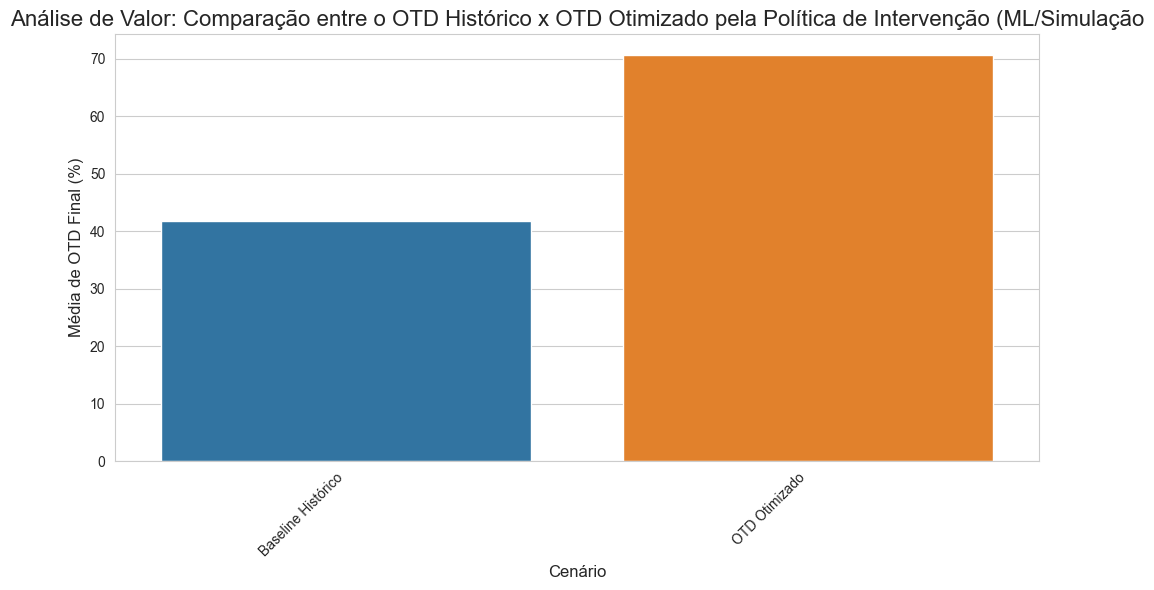

In [8]:
# análise gráfica do crescimento de performance com aplicação de política corretiva gerada por previsão do modelo.

otd_simulado_final = (tbl_simulacao['is_otd_corrigido'] == 1).mean()

dados_conclusao = pd.DataFrame({
    'Cenário': ['Baseline Histórico', 'OTD Otimizado'],
    'OTD Final (%)': [otd_baseline * 100, otd_simulado_final * 100]})

grafico_coluna(x_col='Cenário', y_col='OTD Final (%)', df=dados_conclusao, hue_col='Cenário',
               title='Análise de Valor: Comparação entre o OTD Histórico x OTD Otimizado pela Política de Intervenção (ML/Simulação')


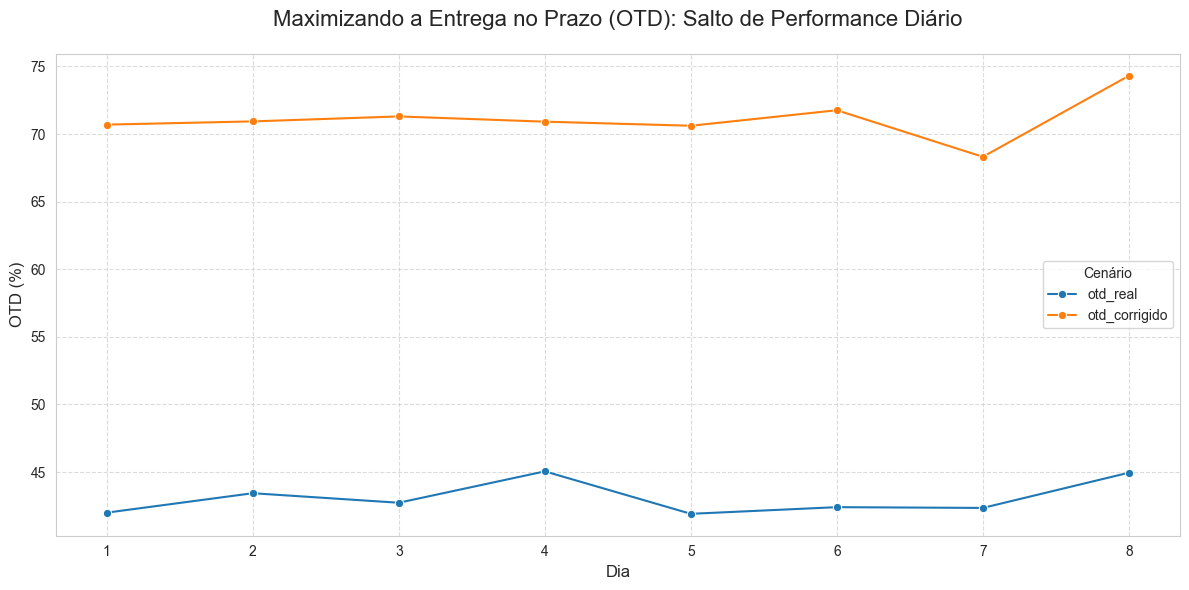

In [9]:
# análise da performance diária entre o OTD com e sem política corretiva.

resultado_diario = tbl_simulacao.groupby('dia').agg(otd_real=('tempo_real_min', lambda x: (x <=120).sum() / len(x)), 
                                                    otd_corrigido=('tempo_corrigido_min', lambda x: (x <=120).sum() / len(x))).reset_index()
    
resultado_diario = resultado_diario.melt(
    id_vars='dia', 
    value_vars=['otd_real', 'otd_corrigido'], 
    var_name='Cenário', 
    value_name='OTD (%)'
)
resultado_diario['OTD (%)'] = resultado_diario['OTD (%)'] * 100

grafico_lineplot(
    df=resultado_diario, 
    x_col='dia', 
    y_col='OTD (%)',
    hue_col='Cenário',
    titulo='Maximizando a Entrega no Prazo (OTD): Salto de Performance Diário'
)


## Eficiência Operacional

c:\Users\ederr\Documents\PROJETOS_PYTHON\projetos_fiap\Fase_3\tech_challenge_ml_engineer_phase3\src\visualization\static_plot.py:274: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


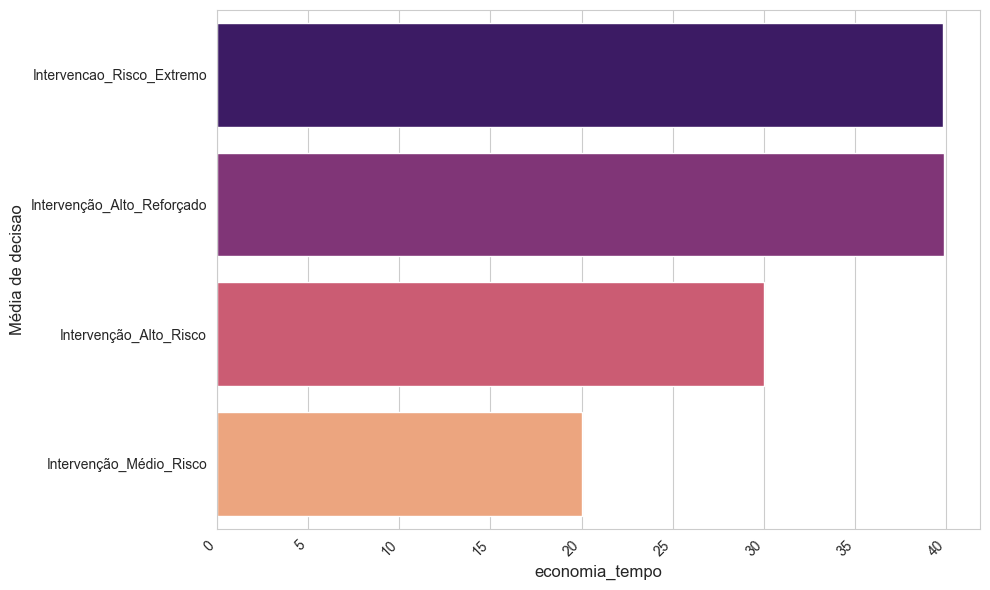

In [10]:
# tempo médio ganho em cada processo de intervenção
df_ganho = tbl_simulacao[tbl_simulacao['decisao'] != 'Nenhuma'].groupby('decisao')['economia_tempo'].mean().reset_index()

# Ordena pelo maior ganho
ordem_decisoes = df_ganho.sort_values(by='economia_tempo', ascending=False)['decisao']

grafico_coluna(x_col='economia_tempo', y_col='decisao', df=df_ganho, palette='magma')


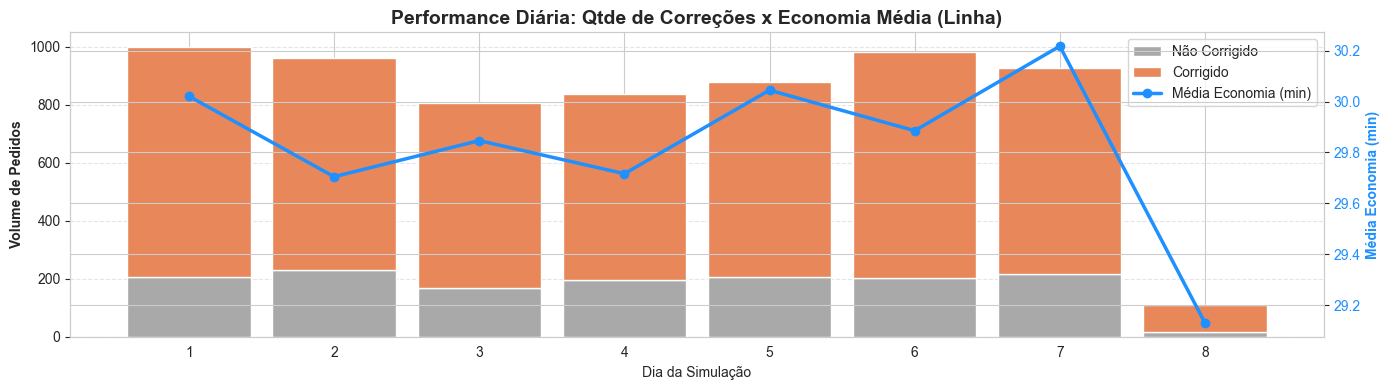

In [11]:
# comparativo entre a quantidade de pedidos com intervenção e a média de economia gerada 
df = tbl_simulacao.copy()
df['Tipo_Pedido'] = np.where(df['decisao'] == 'Nenhuma', 'Nao Corrigido', 'Corrigido')


df_stacked = df.groupby(['dia','Tipo_Pedido']).size().unstack(fill_value=0).reset_index()
df_stacked['Total'] = df_stacked['Nao Corrigido'] + df_stacked['Corrigido']
df_stacked = df_stacked.rename(columns={"NÃ£o Corrigido": "Não Corrigido"})


df_economia = (df[df['decisao'] != 'Nenhuma']
               .groupby('dia')['economia_tempo']
               .mean().reset_index(name='media'))

df_plot = df_stacked[['dia']].merge(df_economia, on='dia', how='left').fillna(0)


plot_performance(df_stacked, df_plot, coluna_linha='media')


In [12]:
# análise descritiva do resultado de simulacão
tbl_simulacao.describe()

,previsao_min,tempo_real_min,tempo_corrigido_min,delivery_distance,tempo_coleta,Agent_Rating,Agent_Age,is_grocery,jam_or_high_traffic,is_sunny_weather,...,tempo_conclusao_sim,is_otd_corrigido,dia,economia_tempo,res,res_corr,corr,dist_gte_10,Area_Metropolitian,Area_Semi-Urban
count,6500.000000,6500.000000,6500.000000,6500.000000,6500.000000,6500.000000,6500.000000,6500.000000,6500.000000,6500.000000,...,6500.000000,6500.000000,6500.000000,6500.000000,6500.000000,6500.000000,6500.000000,6500.000000,6500.000000,6500.000000
mean,107.034604,122.581926,99.327068,9.471485,9.959231,4.700373,26.473692,0.202308,0.695385,0.198769,...,5202.723135,0.707077,4.051538,23.254858,15.547322,-7.707535,23.254858,0.449846,0.761538,0.002923
std,45.623963,48.916202,41.948673,5.495314,4.095607,0.199734,5.756142,0.401751,0.460280,0.399105,...,3019.912754,0.455138,2.095054,14.124674,11.169745,16.934704,14.124674,0.497517,0.426176,0.053991
min,24.200543,5.000000,5.000000,0.000000,5.000000,3.855318,4.000000,0.000000,0.000000,0.000000,...,15.296835,0.000000,1.000000,0.000000,-21.957405,-61.957405,0.000000,0.000000,0.000000,0.000000
25%,89.004599,100.224453,73.308126,4.943682,5.000000,4.562773,23.000000,0.000000,0.000000,0.000000,...,2495.743969,0.000000,2.000000,20.000000,7.849169,-19.875201,20.000000,0.000000,1.000000,0.000000
50%,109.185061,125.798877,98.577623,8.709158,10.000000,4.700895,27.000000,0.000000,1.000000,0.000000,...,5294.422520,1.000000,4.000000,30.000000,15.412087,-8.887534,30.000000,0.000000,1.000000,0.000000
75%,130.003886,153.324008,126.717567,14.183059,15.000000,4.834529,30.000000,0.000000,1.000000,0.000000,...,7903.210778,1.000000,6.000000,30.000000,23.238031,3.656169,30.000000,1.000000,1.000000,0.000000
max,242.774719,255.886187,236.219786,26.234064,15.000000,5.394008,50.000000,1.000000,1.000000,1.000000,...,10408.871732,1.000000,8.000000,40.000000,55.895815,55.895815,40.000000,1.000000,1.000000,1.000000


<Axes: >

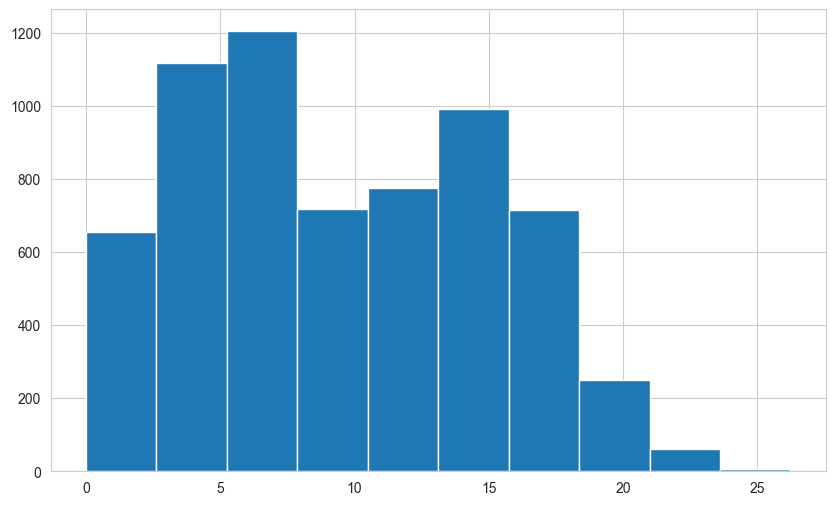

In [13]:
# concenttração de pedidos pelas distância da entrega
tbl_simulacao.delivery_distance.hist()

# Conexão ML=Negócio

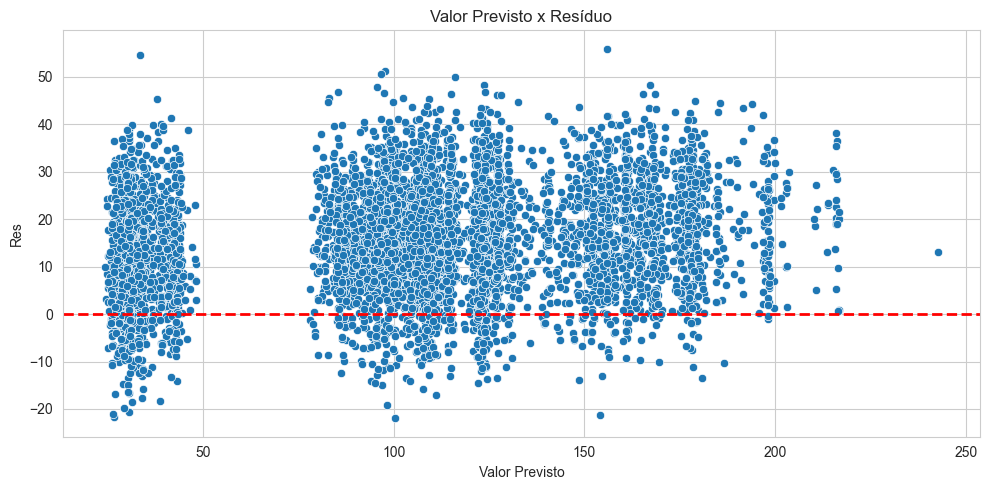

In [14]:
# análise do resíduo de previsão do modelo
grafico_dispersao(df=tbl_simulacao, y=tbl_simulacao['res'],
                          x=tbl_simulacao['previsao_min'],
                          titulo='Valor Previsto x Resíduo', ylabel='Res', xlabel='Valor Previsto',res=True)


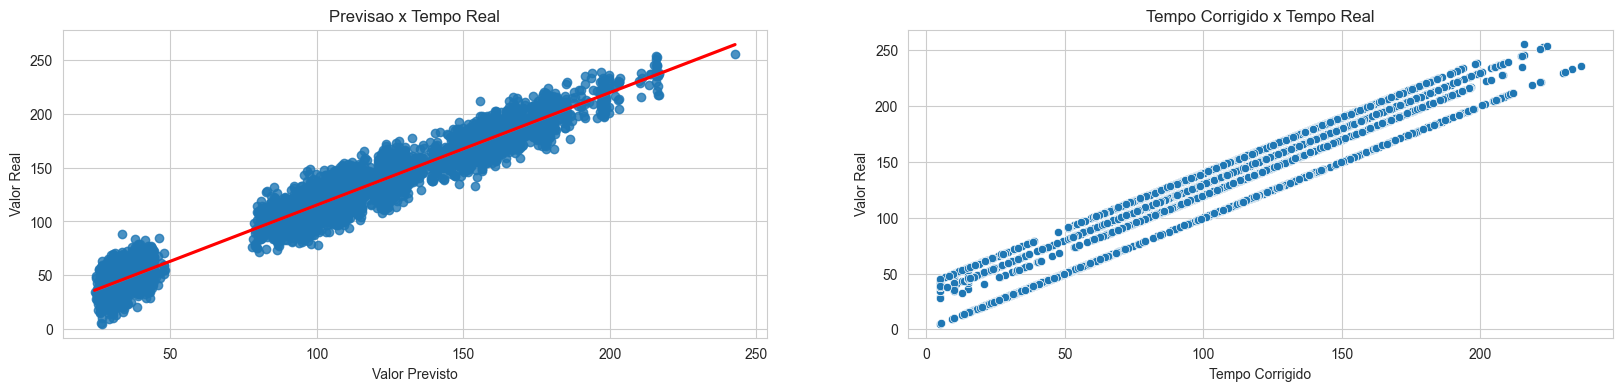

In [15]:
# comparativo entre valor real e previsto e real e correção
fig, ax = plt.subplots(1,2, figsize=(20,4))
grafico_dispersao(df=tbl_simulacao, y=tbl_simulacao['tempo_real_min'],
                          x=tbl_simulacao['previsao_min'],
                          titulo='Previsao x Tempo Real', ylabel='Valor Real', xlabel='Valor Previsto',regr=True, ax=ax[0])
grafico_dispersao(df=tbl_simulacao, y=tbl_simulacao['tempo_real_min'],
                          x=tbl_simulacao['tempo_corrigido_min'],
                          titulo='Tempo Corrigido x Tempo Real', ylabel='Valor Real', xlabel='Tempo Corrigido',  ax=ax[1])

In [16]:
tbl_simulacao.columns

Index(['id_pedido', 'previsao_min', 'tempo_real_min', 'tempo_corrigido_min',
       'delivery_distance', 'tempo_coleta', 'Agent_Rating', 'Agent_Age',
       'Vehicle', 'Weather', 'Traffic', 'Area', 'weekend', 'is_grocery',
       'jam_or_high_traffic', 'is_sunny_weather', 'tempo_criacao_sim',
       'tempo_conclusao_sim', 'decisao', 'is_otd_corrigido', 'dia',
       'economia_tempo', 'res', 'res_corr', 'corr', 'dist_gte_10',
       'Area_Metropolitian', 'Area_Semi-Urban'],
      dtype='object')

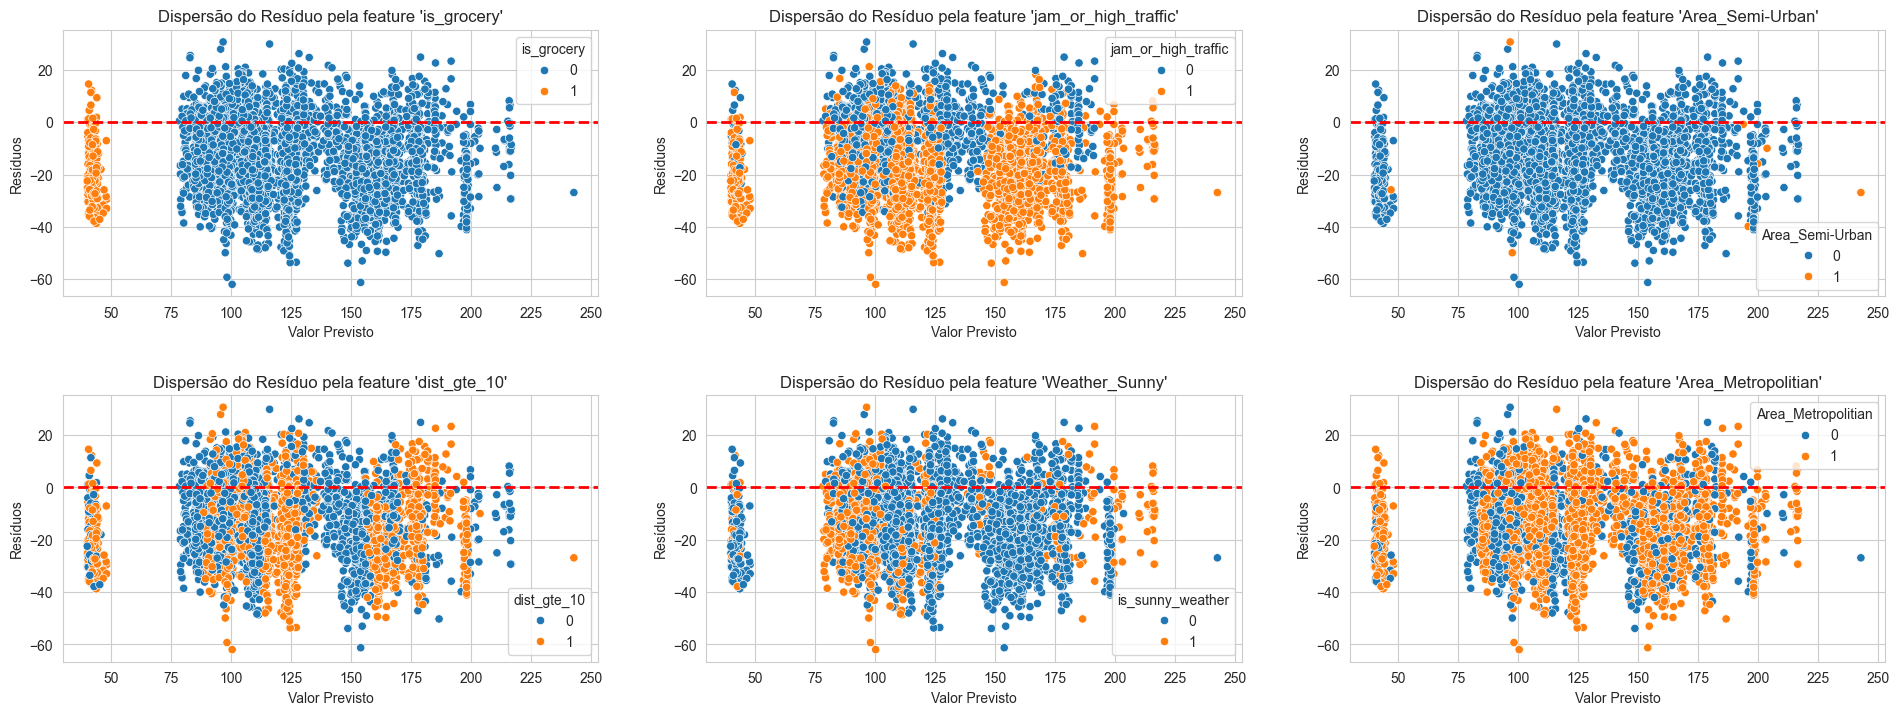

In [17]:
# comparação da melhoria de resultado do baseline com ajuste de hiper-paramâmetros
tbl_simulacao = tbl_simulacao[tbl_simulacao['decisao'] != 'Nenhuma']
fig,ax = plt.subplots(2,3, figsize=(20,8))
plt.tight_layout(pad=5)
grafico_dispersao(df=tbl_simulacao, y=tbl_simulacao['res_corr'],
                          x=tbl_simulacao['previsao_min'],
                          titulo="Dispersão do Resíduo pela feature 'is_grocery'", ylabel='Resíduos', xlabel='Valor Previsto', res=True, hue = 'is_grocery', ax=ax[0][0])

grafico_dispersao(df=tbl_simulacao, y=tbl_simulacao['res_corr'],
                          x=tbl_simulacao['previsao_min'],
                          titulo="Dispersão do Resíduo pela feature 'jam_or_high_traffic'", ylabel='Resíduos', xlabel='Valor Previsto', res=True, hue = 'jam_or_high_traffic', ax=ax[0][1])

grafico_dispersao(df=tbl_simulacao, y=tbl_simulacao['res_corr'],
                          x=tbl_simulacao['previsao_min'],
                          titulo="Dispersão do Resíduo pela feature 'dist_gte_10'", ylabel='Resíduos', xlabel='Valor Previsto', res=True, hue = 'dist_gte_10', ax=ax[1][0])

grafico_dispersao(df=tbl_simulacao, y=tbl_simulacao['res_corr'],
                          x=tbl_simulacao['previsao_min'],
                          titulo="Dispersão do Resíduo pela feature 'Weather_Sunny'", ylabel='Resíduos', xlabel='Valor Previsto', res=True, hue = 'is_sunny_weather', ax=ax[1][1])
grafico_dispersao(df=tbl_simulacao, y=tbl_simulacao['res_corr'],
                          x=tbl_simulacao['previsao_min'],
                          titulo="Dispersão do Resíduo pela feature 'Area_Semi-Urban'", ylabel='Resíduos', xlabel='Valor Previsto', res=True, hue = 'Area_Semi-Urban', ax=ax[0][2])
grafico_dispersao(df=tbl_simulacao, y=tbl_simulacao['res_corr'],
                          x=tbl_simulacao['previsao_min'],
                          titulo="Dispersão do Resíduo pela feature 'Area_Metropolitian'", ylabel='Resíduos', xlabel='Valor Previsto', res=True, hue = 'Area_Metropolitian', ax=ax[1][2])